# Special `_MIX` Reference State

`pycalphad` also includes special mixing reference state that is referenced to the end members for that phase with the `_MIX` suffix (`GM_MIX`, `HM_MIX`, `SM_MIX`, `CPM_MIX`). This is particularly useful for seeing how the mixing contributions from physical or excess models affect the energy.

Below is an example for calculating this end member-referenced mixing enthalpy for the $\chi$ phase in `Nb-Re`. Notice that the four end members have a mixing enthalpy of zero.

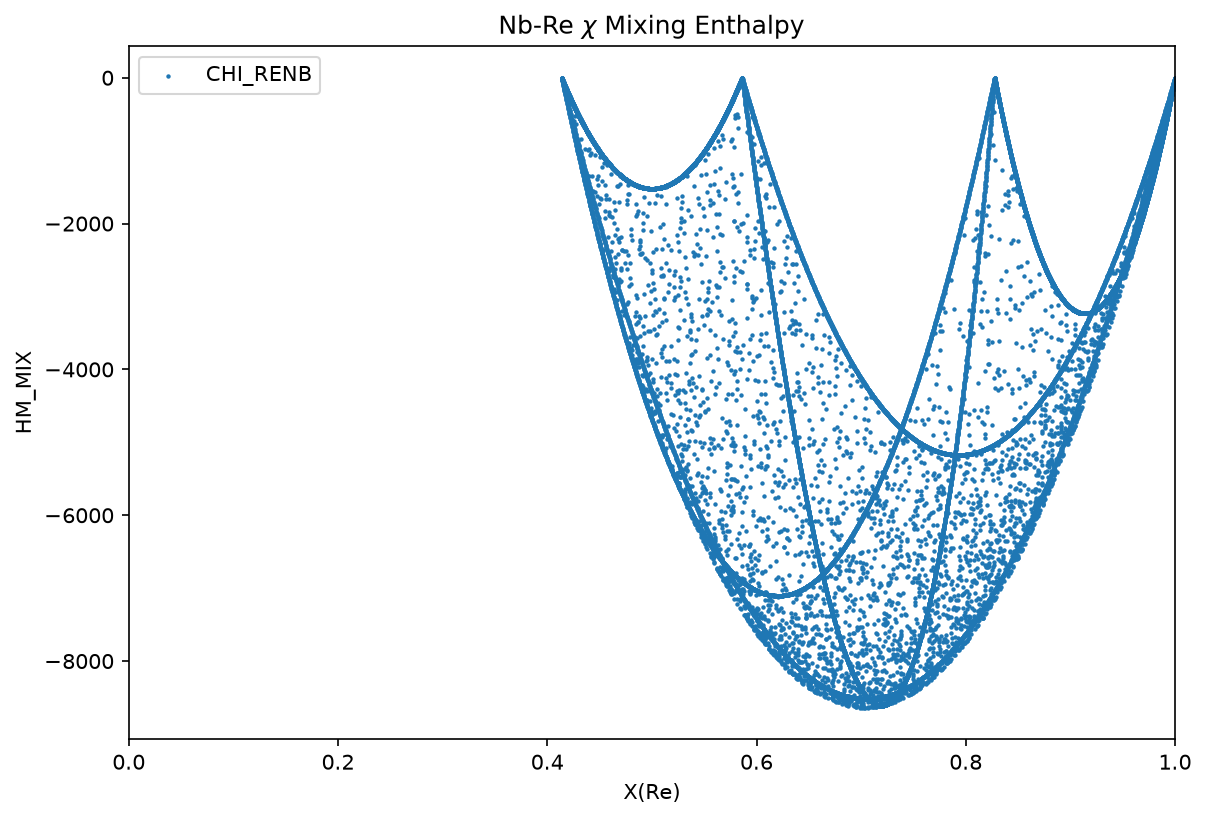

In [1]:
from pycalphad import Database, calculate
import matplotlib.pyplot as plt

dbf = Database("../databases/nbre_liu.tdb")
comps = ["NB", "RE", "VA"]
phases = "CHI_RENB"

# Calculate HMR for the Chi phase at 2800 K from X(Re)=0 to X(Re)=1
result = calculate(dbf, comps, phases, N=1, P=101325, T=2800, output='HM_MIX')

# Plot
fig = plt.figure(figsize=(9,6), dpi=150)
ax = fig.gca()
ax.scatter(result.X.sel(component='RE'), result.HM_MIX, marker='.', s=5, label='CHI_RENB')
ax.set_xlim((0, 1))
ax.set_xlabel('X(Re)')
ax.set_ylabel('HM_MIX')
ax.set_title('Nb-Re $\\chi$ Mixing Enthalpy')
ax.legend()
plt.show()

## Calculations at specific site fractions

In the previous example, the mixing energy for the $\chi$ phase in Nb-Re is sampled by sampling site fractions linearly between end members and then randomly across site fraction space.

Imagine now that you'd like to calculate the mixing energy along a single internal degree of freedom (i.e. between two end members), referenced to those end members.

A custom 2D site fraction array can be passed to the `points` argument of `calculate` and the `HM_MIX` property can be calculated as above.

The sublattice model for $\chi$ is (Re : Nb,Re : Nb,Re).

If we are interested in the interaction along the second sublattice when Nb occupies the third sublattice, we need to construct a site fraction array of 

```python
# Re, Nb, Re, Nb, Re
[ 1.0, x, 1-x, 1.0, 0.0 ]
```

where `x` varies from 0 to 1. This fixes the site fraction of Re in the first sublattice to 1 and the site fractions of `Nb` and `Re` in the third sublattice to 1 and 0, respectively. Note that the site fraction array is sorted first in sublattice order, then in alphabetic order within each sublattice (e.g. Nb is always before Re within a sublattice)



In [2]:
from pycalphad import Database, calculate
import numpy as np
import matplotlib.pyplot as plt

dbf = Database("../databases/nbre_liu.tdb")
comps = ["NB", "RE", "VA"]

# The values for the internal degree of freedom we will vary
n_pts = 1001
x = np.linspace(1e-12, 1, n_pts)

# Create the site fractions
# The site fraction array is ordered first by sublattice, then alphabetically be species within a sublattice.
# The site fraction array is therefore `[Re#0, Nb#1, Re#1, Nb#2, Re#2]`, where `#0` is the sublattice at index 0.
# To calculate a Re:Nb,Re:Nb interaction requires the site fraction array to be [1, x, 1-x, 1, 0]
# Note the 1-x is required for site fractions to sum to 1 in sublattice #1.
site_fractions = np.array([np.ones(n_pts), x, 1-x, np.ones(n_pts), np.zeros(n_pts)]).T
print('Site fractions:')
print(site_fractions)
print('Site fractions shape: {} ({} points, {} internal degrees of freedom)'.format(site_fractions.shape, site_fractions.shape[0], site_fractions.shape[1]))

Site fractions:
[[1.00e+00 1.00e-12 1.00e+00 1.00e+00 0.00e+00]
 [1.00e+00 1.00e-03 9.99e-01 1.00e+00 0.00e+00]
 [1.00e+00 2.00e-03 9.98e-01 1.00e+00 0.00e+00]
 ...
 [1.00e+00 9.98e-01 2.00e-03 1.00e+00 0.00e+00]
 [1.00e+00 9.99e-01 1.00e-03 1.00e+00 0.00e+00]
 [1.00e+00 1.00e+00 0.00e+00 1.00e+00 0.00e+00]]
Site fractions shape: (1001, 5) (1001 points, 5 internal degrees of freedom)


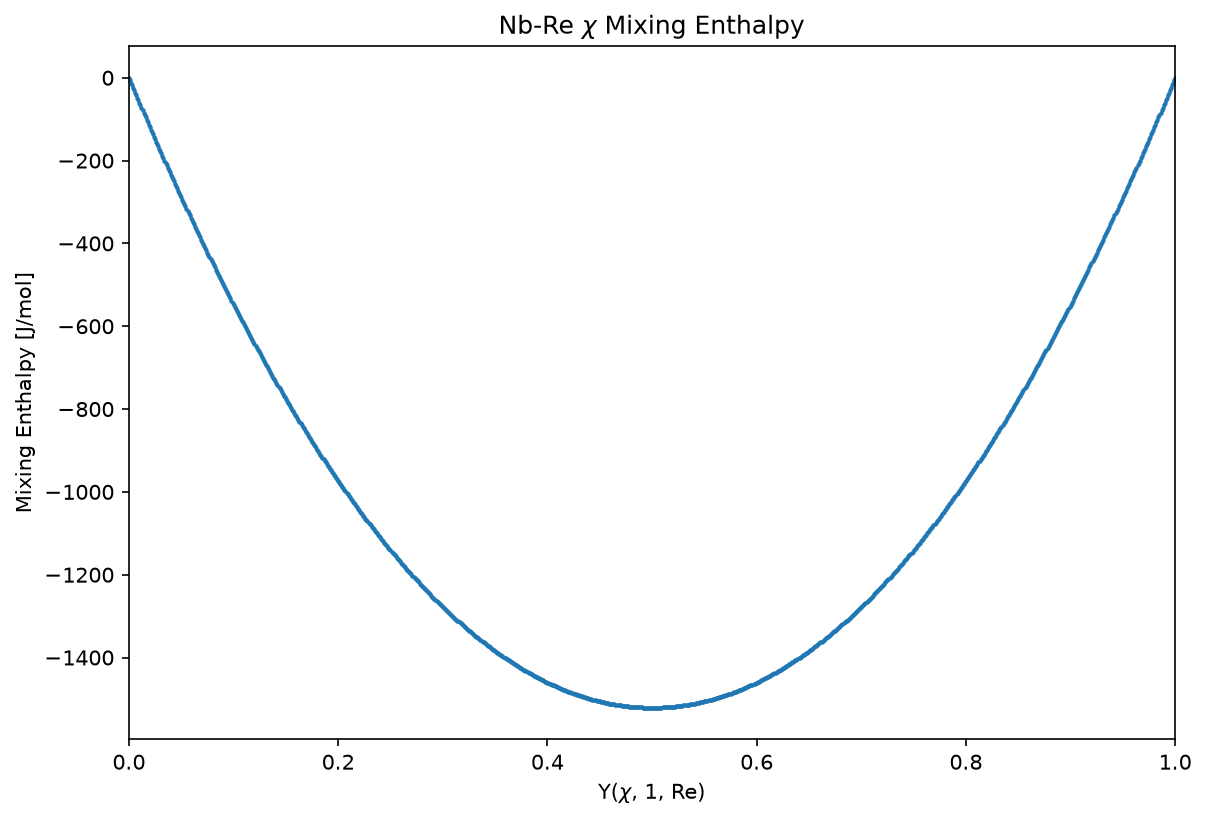

In [3]:
# Calculate HMR for the Chi at 2800 K from Y(CHI, 1, RE)=0 to Y(CHI, 1, RE)=1
# Pass the custom site fractions to the `points` argument
result = calculate(dbf, comps, "CHI_RENB", N=1, P=101325, T=2800, points=site_fractions, output='HM_MIX')

# Extract the site fractions of Re in sublattice 1.
Y_CHI_1_RE = result.Y.squeeze()[:, 2]

# Plot
fig = plt.figure(figsize=(9,6), dpi=150)
ax = fig.gca()

ax.scatter(Y_CHI_1_RE, result.HM_MIX, marker='.', s=5)
ax.set_xlim((0, 1))
ax.set_xlabel('Y($\\chi$, 1, Re)')
ax.set_ylabel('Mixing Enthalpy [J/mol]')
ax.set_title('Nb-Re $\\chi$ Mixing Enthalpy')
plt.show()